In [3]:
from __future__ import annotations

import argparse
import json
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, Tuple

import numpy as np

from pycolleff.colleff import Ring
from pycolleff.longitudinal_equilibrium import (
    LongitudinalEquilibrium,
    ImpedanceSource,
)

from functools import partial

import numpy as np
import matplotlib.pyplot as plt

from pycolleff.longitudinal_equilibrium import ImpedanceSource, LongitudinalEquilibrium
import pycolleff.rings.sirius as sirius
import pycolleff.impedances as imp
import pycolleff.materials_params as mat_par

In [4]:
@dataclass
class GridConfig:
    nz: int = 512
    sigmas: float = 6.0
    
def calculate_longitudinal_equilibrium(ring, impedance_sources, fill=None):
    """
    Calculate longitudinal equilibrium.
    """
    if fill is None:
        fill = np.ones(ring.harm_num) / ring.harm_num
    longeq = LongitudinalEquilibrium(
        ring=ring, impedance_sources=impedance_sources, fillpattern=fill)
    longeq.feedback_on = False  # main cavity is simulated with effective impedance
    longeq.zgrid = np.linspace(-1, 1, 2001) * ring.rf_lamb / 2
    longeq.max_mode = 1000*ring.harm_num  # define maximum frequency to consider
    longeq.min_mode0_ratio = 1e-10  # criteria for convergence

    print('Calculating Longitudinal Equilibrium...')
    _ = longeq.calc_longitudinal_equilibrium(
        niter=1000, tol=1e-8, beta=0.1, m=3, print_flag=True)
    return longeq


def print_results(longeq: LongitudinalEquilibrium, gc: GridConfig, uniform=True) -> None:
    """
    Print and plot the results of longitudinal equilibrium.
    """
    z0, sigmaz = longeq.calc_moments(longeq.zgrid, longeq.distributions)
    n_sigmas = gc.sigmas
    if uniform:
        print(f'Bunch 0 centroid: {z0[0]*1e3:.2f} mm')
        print(f'Bunch 0 length: {sigmaz[0]*1e3:.2f} mm')
        plt.figure()
        plt.plot(longeq.zgrid*1e3, longeq.distributions[0])
        plt.xlabel(r'$z$ [mm]')
        plt.ylabel(r'$\lambda(z)$ [1/mm]')
        plt.xlim((z0-n_sigmas*sigmaz)*1e3, (z0+n_sigmas*sigmaz)*1e3)
        plt.tight_layout()
        plt.show()
    else:
        fig, (af, ax, ay) = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
        fill = longeq.fillpattern.copy()
        idcs = np.arange(fill.size)
        zef = np.isclose(fill, 0)
        af.plot(idcs, fill*longeq.ring.total_current*1e3, 'o')
        ax.plot(idcs[~zef], z0[~zef]*1e3, 'o')
        ay.plot(idcs[~zef], sigmaz[~zef]*1e3, 'o')
        ax.plot(idcs[zef], z0[zef]*1e3, 'o', color='gray')
        ay.plot(idcs[zef], sigmaz[zef]*1e3, 'o', color='gray')
        af.set_ylabel('Filling Pattern [mA]')
        ax.set_ylabel('Centroid [mm]')
        ay.set_ylabel('Bunch Length [mm]')
        ay.set_xlabel('Bunch Index')
        fig.tight_layout()
        plt.show()


@dataclass
class DatasetConfig:
    n_samples: int = 512
    particles_per_sample: int = 4096
    seed: int = 42
    output_dir: str = "./data/neural"
    train_fraction: float = 0.8
    val_fraction: float = 0.1





@dataclass
class RingConfig:
    energy_eV: float = 3.0e9
    rf_freq_Hz: float = 500e6
    harm_num: int = 1
    mom_comp: float = 1.7e-4
    sync_tune: float = 0.004
    espread: float = 8.0e-4
    bunlen_m: float = 4.0e-3
    en_lost_rad_eV: float = 8.0e5
    gap_voltage_V: float = 3.0e6
    total_current_A: float = 0.1


@dataclass
class ParameterRanges:
    # mu will be interpreted as [en_lost_rad_eV, gap_voltage_V, total_current_A]
    en_lost_rad_eV: Tuple[float, float] = (5.0e5, 1.2e6)
    gap_voltage_V: Tuple[float, float] = (2.0e6, 5.0e6)
    total_current_A: Tuple[float, float] = (0.02, 0.30)


@dataclass
class ResonatorConfig:
    Q: float = 1.0e4
    wr_scale_to_rf: float = 3.0   # resonator angular freq = wr_scale * rf_ang_freq
    harm_rf: int = 3


@dataclass
class RelaxationConfig:
    n_steps: int = 3
    mix: float = 0.7   # under-relaxation: dist <- (1-mix) dist + mix new_dist
    



def normalize_density(z: np.ndarray, lam: np.ndarray) -> np.ndarray:
    lam = np.maximum(lam, 0.0)
    area = np.trapz(lam, z)
    if area <= 0:
        raise ValueError("Density integral must be positive.")
    return lam / area


def sample_mu(rng: np.random.Generator, pr: ParameterRanges) -> np.ndarray:
    # return order: [en_lost_rad_eV, gap_voltage_V, total_current_A]
    return np.array(
        [
            rng.uniform(*pr.gap_voltage_V),
            rng.uniform(*pr.total_current_A),
            rng.uniform(*pr.en_lost_rad_eV)
        ],
        dtype=np.float64,
    )


def build_ring(base: RingConfig, mu: np.ndarray) -> Ring:
    ring = Ring()
    ring.energy = base.energy_eV
    ring.rf_freq = base.rf_freq_Hz
    ring.harm_num = base.harm_num
    ring.num_bun = base.harm_num
    ring.mom_comp = base.mom_comp
    ring.sync_tune = base.sync_tune
    ring.espread = base.espread
    ring.bunlen = base.bunlen_m
    ring.en_lost_rad = base.en_lost_rad_eV

    # MU[0], MU[1], MU[2] are interpreted according to ParameterRanges
    # caller may override ring parameters after creation as needed
    ring.gap_voltage = base.gap_voltage_V
    ring.total_current = base.total_current_A
    return ring


def build_impedance_sources(
    ring: Ring,
    mu: np.ndarray,
    resonator_cfg: ResonatorConfig,
) -> list[ImpedanceSource]:
    # This function can be adapted to use mu semantics when needed.
    # Currently, mu[0]=en_lost_rad_eV, mu[1]=gap_voltage_V, mu[2]=total_current_A
    # Example: build a simple resonator source based on resonator_cfg and ring
    src = ImpedanceSource(
        Rs=float(1.0e4),  # placeholder; adapt if you want mu to carry shunt impedance
        Q=float(resonator_cfg.Q),
        ang_freq=float(resonator_cfg.wr_scale_to_rf * ring.rf_ang_freq),
        harm_rf=int(resonator_cfg.harm_rf),
        calc_method=ImpedanceSource.Methods.ImpedanceDFT,
    )
    src.ang_freq_rf = ring.rf_ang_freq
    return [src]


def make_input_profile(
    z: np.ndarray,
    rng: np.random.Generator,
) -> np.ndarray:
    # diverse 1D family, but still simple enough for your current FNO
    family = rng.integers(0, 4)

    if family == 0:
        # centered gaussian
        sigma = rng.uniform(0.5e-3, 1.8e-3)
        z0 = rng.uniform(-0.3e-3, 0.3e-3)
        lam = np.exp(-0.5 * ((z - z0) / sigma) ** 2)

    elif family == 1:
        # off-centered gaussian
        sigma = rng.uniform(0.7e-3, 2.2e-3)
        z0 = rng.uniform(-1.2e-3, 1.2e-3)
        lam = np.exp(-0.5 * ((z - z0) / sigma) ** 2)

    elif family == 2:
        # two-gaussian mixture
        sigma1 = rng.uniform(0.5e-3, 1.5e-3)
        sigma2 = rng.uniform(0.5e-3, 1.8e-3)
        z01 = rng.uniform(-1.3e-3, -0.2e-3)
        z02 = rng.uniform(0.2e-3, 1.3e-3)
        a2 = rng.uniform(0.3, 0.9)
        lam = np.exp(-0.5 * ((z - z01) / sigma1) ** 2)
        lam += a2 * np.exp(-0.5 * ((z - z02) / sigma2) ** 2)

    else:
        # slightly modulated gaussian
        sigma = rng.uniform(0.8e-3, 1.8e-3)
        eps = rng.uniform(0.05, 0.25)
        k = rng.integers(2, 6)
        base = np.exp(-0.5 * (z / sigma) ** 2)
        lam = base * (1.0 + eps * np.cos(2 * np.pi * k * (z - z.min()) / (z.ptp() + 1e-15)))

    return normalize_density(z, lam).astype(np.float64)


def one_relaxation_map(
    leq: LongitudinalEquilibrium,
    dist_in: np.ndarray,              # shape (1, Nz)
    relax_cfg: RelaxationConfig,
) -> np.ndarray:
    """
    Apply a small number of collective-effect relaxation steps.
    This preserves dependence on lambda_in, which is what your current model needs.
    """
    dist = dist_in.copy()

    for _ in range(relax_cfg.n_steps):
        v_main = leq.main_voltage[0]  # shape (Nz,)
        v_ind = leq.calc_induced_voltage_impedance_dft(dist=dist)[0]
        v_tot = v_main + v_ind

        dist_new, _ = leq.calc_distributions_from_voltage(v_tot)
        # dist_new has shape (harm_num, Nz). Here harm_num=1.
        dist = (1.0 - relax_cfg.mix) * dist + relax_cfg.mix * dist_new[:1]

        # renormalize explicitly for safety
        dist[0] = normalize_density(leq.zgrid, dist[0])

    return dist


def split_indices(
    n: int,
    train_fraction: float,
    val_fraction: float,
    rng: np.random.Generator,
) -> Dict[str, np.ndarray]:
    perm = rng.permutation(n)
    n_train = int(round(train_fraction * n))
    n_val = int(round(val_fraction * n))
    return {
        "train": perm[:n_train],
        "val": perm[n_train:n_train + n_val],
        "test": perm[n_train + n_val:],
    }


def generate_dataset(
    dataset_cfg: DatasetConfig,
    grid_cfg: GridConfig,
    ring_cfg: RingConfig,
    param_ranges: ParameterRanges,
    resonator_cfg: ResonatorConfig,
    relax_cfg: RelaxationConfig,
) -> Dict[str, np.ndarray]:
    rng = np.random.default_rng(dataset_cfg.seed)

    X_lambda = []
    Y_lambda = []
    X_cloud = []
    Y_cloud = []
    MU = []

    zeta_grid_ref = None

    for _ in range(dataset_cfg.n_samples):
        mu = sample_mu(rng, param_ranges)

        ring = sirius.create_ring()
        ring.harm_num = 1
        ring.num_bun = 1
        # Update ring parameters based on mu
        
        ring.gap_voltage = float(mu[0])
        ring.total_current = float(mu[1])
        ring.en_lost_rad = float(mu[2])

        # Build impedance sources
        hcav = ImpedanceSource()
        hcav.harm_rf = resonator_cfg.harm_rf
        hcav.Q = resonator_cfg.Q
        RoverQ = 87.5
        hcav.shunt_impedance = RoverQ * hcav.Q
        twopi = 2 * np.pi
        hcav.ang_freq_rf = twopi * ring.rf_freq
        hcav.ang_freq = hcav.harm_rf * hcav.ang_freq_rf
        hcav.detune_w = twopi * 45e3
        hcav.calc_method = ImpedanceSource.Methods.ImpedanceDFT
        hcav.active_passive = ImpedanceSource.ActivePassive.Passive

        # Material and geometry parameters
        cu_cond = 59e6
        cu_rel_time = 2.7e-14
        neg_cond = 1e6
        neg_rel_time = 0.0
        neg_thick = 1e-6
        ndfe_cond = 1e6
        ndfe_mur = 40

        energy = 3e9  # [eV]
        length = 500  # [m]

        epb = np.array([1, 1, 1, 1, 1])
        mub = np.array([1, 1, 1, 1, ndfe_mur])
        ange = np.array([0, 0, 0, 0, 0])
        angm = np.array([0, 0, 0, 0, 0])
        sigmadc = np.array([0, neg_cond, cu_cond, 0, ndfe_cond])
        tau = np.array([0, neg_rel_time, cu_rel_time, 0, 0])

        radius = 12e-3 + np.array([-neg_thick, 0, 1e-3, 3e-3])

        ang_freq = imp.get_default_reswall_w(radius=radius[0], energy=energy)

        epr, mur = imp.prepare_inputs_epr_mur(
            ang_freq, epb, mub, ange, angm, sigmadc, tau)

        Zll, Zdx, Zdy = imp.multilayer_round_chamber(
            ang_freq,
            length,
            energy,
            epr,
            mur,
            radius,
            precision=70,
            wmax_arb_prec=1e12,
            arb_prec_incl_long=False,
            print_progress=True,
        )

        Zll, ang_freq = imp.get_impedance_for_negative_w(
            Zll, ang_freq, impedance_type='ll'
        )

        generic = ImpedanceSource()
        generic.zl_table = Zll
        generic.ang_freq_table = ang_freq
        generic.calc_method = ImpedanceSource.Methods.ImpedanceDFT
        generic.active_passive = ImpedanceSource.ActivePassive.Passive

        # Combine impedance sources
        impedance_sources = [generic, hcav]

        fillpattern = np.ones(ring.harm_num, dtype=float)
        fillpattern /= fillpattern.sum()

        leq = LongitudinalEquilibrium(
            ring=ring,
            impedance_sources=impedance_sources,
            fillpattern=fillpattern,
        )
       
        zgrid = leq.create_zgrid(nr_points=grid_cfg.nz, sigmas=grid_cfg.sigmas)
        leq.zgrid = zgrid

        lam_in = make_input_profile(zgrid, rng)
        dist_in = lam_in[None, :]   # shape (1, Nz)

        dist_out = one_relaxation_map(leq, dist_in, relax_cfg)
        lam_out = dist_out[0]

        # clouds sampled from the 1D densities
        zeta_in_cloud = sample_cloud_from_density(
            zgrid, lam_in, dataset_cfg.particles_per_sample, rng
        )
        zeta_out_cloud = sample_cloud_from_density(
            zgrid, lam_out, dataset_cfg.particles_per_sample, rng
        )

        x_cloud = embed_zeta_cloud_in_6d(zeta_in_cloud)
        y_cloud = embed_zeta_cloud_in_6d(zeta_out_cloud)

        if zeta_grid_ref is None:
            zeta_grid_ref = zgrid.astype(np.float32)

        X_lambda.append(lam_in.astype(np.float32))
        Y_lambda.append(lam_out.astype(np.float32))
        X_cloud.append(x_cloud)
        Y_cloud.append(y_cloud)
        MU.append(mu.astype(np.float32))
        print_results(leq, gc=grid_cfg)

    X_lambda = np.stack(X_lambda, axis=0)
    Y_lambda = np.stack(Y_lambda, axis=0)
    X_cloud = np.stack(X_cloud, axis=0)
    Y_cloud = np.stack(Y_cloud, axis=0)
    MU = np.stack(MU, axis=0)

    split = split_indices(
        n=X_lambda.shape[0],
        train_fraction=dataset_cfg.train_fraction,
        val_fraction=dataset_cfg.val_fraction,
        rng=np.random.default_rng(dataset_cfg.seed + 17),
    )

    out = {
        "X_lambda": X_lambda,
        "Y_lambda": Y_lambda,
        "X_cloud": X_cloud,
        "Y_cloud": Y_cloud,
        "MU": MU,
        "zeta_grid": zeta_grid_ref,
        "train": split["train"],
        "val": split["val"],
        "test": split["test"],
    }
    return out


def sample_cloud_from_density(
    zgrid: np.ndarray,
    lam: np.ndarray,
    n_particles: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Sample zeta particles from a 1D line density lambda(zeta).
    Returns shape (n_particles,).
    """
    lam = np.maximum(lam, 0.0)
    cdf = np.cumsum(lam)
    if cdf[-1] <= 0:
        raise ValueError("Density must have positive mass.")
    cdf = cdf / cdf[-1]

    u = rng.uniform(0.0, 1.0, size=n_particles)
    zeta = np.interp(u, cdf, zgrid)
    return zeta.astype(np.float32)


def embed_zeta_cloud_in_6d(zeta_cloud: np.ndarray) -> np.ndarray:
    """
    Build a fake 6D cloud [x, y, zeta, px, py, delta]
    with only zeta populated.
    Shape: (n_particles, 6)
    """
    n = zeta_cloud.shape[0]
    cloud = np.zeros((n, 6), dtype=np.float32)
    cloud[:, 2] = zeta_cloud
    return cloud


def save_dataset(
    data: Dict[str, np.ndarray],
    dataset_cfg: DatasetConfig,
    grid_cfg: GridConfig,
    ring_cfg: RingConfig,
    param_ranges: ParameterRanges,
    resonator_cfg: ResonatorConfig,
    relax_cfg: RelaxationConfig,
) -> None:
    out_dir = Path(dataset_cfg.output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # Save with the SAME filename your existing model already expects.
    np.savez(out_dir / "xsuite_neural_pycolleff_dataset.npz", **data)

    metadata = {
        "generator": "pycolleff",
        "dataset_config": asdict(dataset_cfg),
        "grid_config": asdict(grid_cfg),
        "ring_config": asdict(ring_cfg),
        "parameter_ranges": asdict(param_ranges),
        "resonator_config": asdict(resonator_cfg),
        "relaxation_config": asdict(relax_cfg),
        # reflect new MU semantics
        "mu_semantics": ["en_lost_rad_eV", "gap_voltage_V", "total_current_A"],
        "keys": sorted(data.keys()),
    }
    (out_dir / "xsuite_neural_dataset_metadata.json").write_text(
        json.dumps(metadata, indent=2)
    )


def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument("--n-samples", type=int, default=512)
    p.add_argument("--particles-per-sample", type=int, default=4096)
    p.add_argument("--seed", type=int, default=42)
    p.add_argument("--output-dir", type=str, default="./data/neural")
    p.add_argument("--nz", type=int, default=256)

    p.add_argument("--train-fraction", type=float, default=0.8)
    p.add_argument("--val-fraction", type=float, default=0.1)

    p.add_argument("--gap-voltage-min", type=float, default=2.0e6)
    p.add_argument("--gap-voltage-max", type=float, default=5.0e6)

    p.add_argument("--current-min", type=float, default=0.02)
    p.add_argument("--current-max", type=float, default=0.30)

    p.add_argument("--ev-lost-min", type=float, default=5.0e3)
    p.add_argument("--ev-lost-max", type=float, default=3.0e6)

    p.add_argument("--Q", type=float, default=1.0e4)
    p.add_argument("--wr-scale", type=float, default=3.0)

    p.add_argument("--n-steps", type=int, default=3)
    p.add_argument("--mix", type=float, default=0.7)
    return p.parse_args()


In [5]:


args = argparse.Namespace(
    n_samples=10,
    particles_per_sample=4096,
    nz = 2048,
    seed=42,
    output_dir="./data/neural",
    train_fraction=0.8,
    val_fraction=0.1,
    gap_voltage_min=2.0e6,
    gap_voltage_max=5.0e6,
    current_min=200e-3,
    current_max=300e-3,
    ev_lost_min=800e3,
    ev_lost_max=900e3,
    Q=1.0e4,
    wr_scale=3.0,
    n_steps=3,
    mix=0.7,
)


0000/0302 -> freq =        0.1  (ET: 0.14 s)
0001/0302 -> freq =       0.11  (ET: 0.08 s)
0002/0302 -> freq =       0.12  (ET: 0.08 s)
0003/0302 -> freq =       0.13  (ET: 0.07 s)
0004/0302 -> freq =       0.15  (ET: 0.09 s)
0005/0302 -> freq =       0.16  (ET: 0.07 s)
0006/0302 -> freq =       0.17  (ET: 0.07 s)
0007/0302 -> freq =       0.19  (ET: 0.07 s)
0008/0302 -> freq =       0.21  (ET: 0.07 s)
0009/0302 -> freq =       0.23  (ET: 0.07 s)
0010/0302 -> freq =       0.25  (ET: 0.08 s)
0011/0302 -> freq =       0.28  (ET: 0.08 s)
0012/0302 -> freq =       0.31  (ET: 0.08 s)
0013/0302 -> freq =       0.34  (ET: 0.08 s)
0014/0302 -> freq =       0.37  (ET: 0.08 s)
0015/0302 -> freq =        0.4  (ET: 0.08 s)
0016/0302 -> freq =       0.44  (ET: 0.08 s)
0017/0302 -> freq =       0.49  (ET: 0.10 s)
0018/0302 -> freq =       0.53  (ET: 0.08 s)
0019/0302 -> freq =       0.59  (ET: 0.07 s)
0020/0302 -> freq =       0.64  (ET: 0.08 s)
0021/0302 -> freq =       0.71  (ET: 0.07 s)
0022/0302 

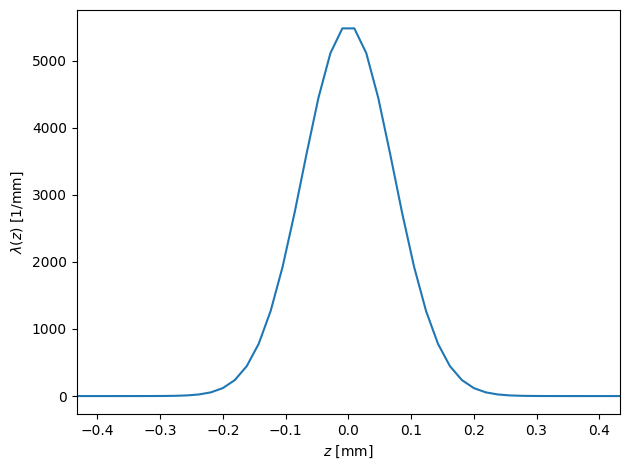

0000/0302 -> freq =        0.1  (ET: 0.08 s)
0001/0302 -> freq =       0.11  (ET: 0.07 s)
0002/0302 -> freq =       0.12  (ET: 0.07 s)
0003/0302 -> freq =       0.13  (ET: 0.07 s)
0004/0302 -> freq =       0.15  (ET: 0.07 s)
0005/0302 -> freq =       0.16  (ET: 0.07 s)
0006/0302 -> freq =       0.17  (ET: 0.07 s)
0003/0302 -> freq =       0.13  (ET: 0.07 s)
0004/0302 -> freq =       0.15  (ET: 0.07 s)
0005/0302 -> freq =       0.16  (ET: 0.07 s)
0006/0302 -> freq =       0.17  (ET: 0.07 s)
0007/0302 -> freq =       0.19  (ET: 0.07 s)
0008/0302 -> freq =       0.21  (ET: 0.07 s)
0009/0302 -> freq =       0.23  (ET: 0.07 s)
0010/0302 -> freq =       0.25  (ET: 0.07 s)
0007/0302 -> freq =       0.19  (ET: 0.07 s)
0008/0302 -> freq =       0.21  (ET: 0.07 s)
0009/0302 -> freq =       0.23  (ET: 0.07 s)
0010/0302 -> freq =       0.25  (ET: 0.07 s)
0011/0302 -> freq =       0.28  (ET: 0.08 s)
0012/0302 -> freq =       0.31  (ET: 0.08 s)
0013/0302 -> freq =       0.34  (ET: 0.07 s)
0011/0302 

KeyboardInterrupt: 

In [6]:
dataset_cfg = DatasetConfig(
    n_samples=args.n_samples,
    particles_per_sample=args.particles_per_sample,
    seed=args.seed,
    output_dir=args.output_dir,
    train_fraction=args.train_fraction,
    val_fraction=args.val_fraction,
)
grid_cfg = GridConfig(nz=args.nz)
ring_cfg = RingConfig()
param_ranges = ParameterRanges(
        gap_voltage_V=(args.gap_voltage_min, args.gap_voltage_max),
        total_current_A=(args.current_min, args.current_max),
        en_lost_rad_eV=(args.ev_lost_min, args.ev_lost_max),
    )
resonator_cfg = ResonatorConfig(Q=args.Q, wr_scale_to_rf=args.wr_scale)
relax_cfg = RelaxationConfig(n_steps=args.n_steps, mix=args.mix)

data = generate_dataset(
        dataset_cfg=dataset_cfg,
        grid_cfg=grid_cfg,
        ring_cfg=ring_cfg,
        param_ranges=param_ranges,
        resonator_cfg=resonator_cfg,
        relax_cfg=relax_cfg,
    )
save_dataset(
        data=data,
        dataset_cfg=dataset_cfg,
        grid_cfg=grid_cfg,
        ring_cfg=ring_cfg,
        param_ranges=param_ranges,
        resonator_cfg=resonator_cfg,
        relax_cfg=relax_cfg,
    )

print("Saved:", Path(dataset_cfg.output_dir) / "xsuite_neural_dataset.npz")
for k, v in data.items():
        print(f"{k}: {v.shape} {v.dtype}")

In [1]:
# print mu ranges for sanity check
print("MU semantics: en_lost_rad_eV, gap_voltage_V, total_current_A")
print("MU ranges:")
print(f"  en_lost_rad_eV: {param_ranges.en_lost_rad_eV}")
print(f"  gap_voltage_V: {param_ranges.gap_voltage_V}")
print(f"  total_current_A: {param_ranges.total_current_A}")

MU semantics: en_lost_rad_eV, gap_voltage_V, total_current_A
MU ranges:


NameError: name 'param_ranges' is not defined

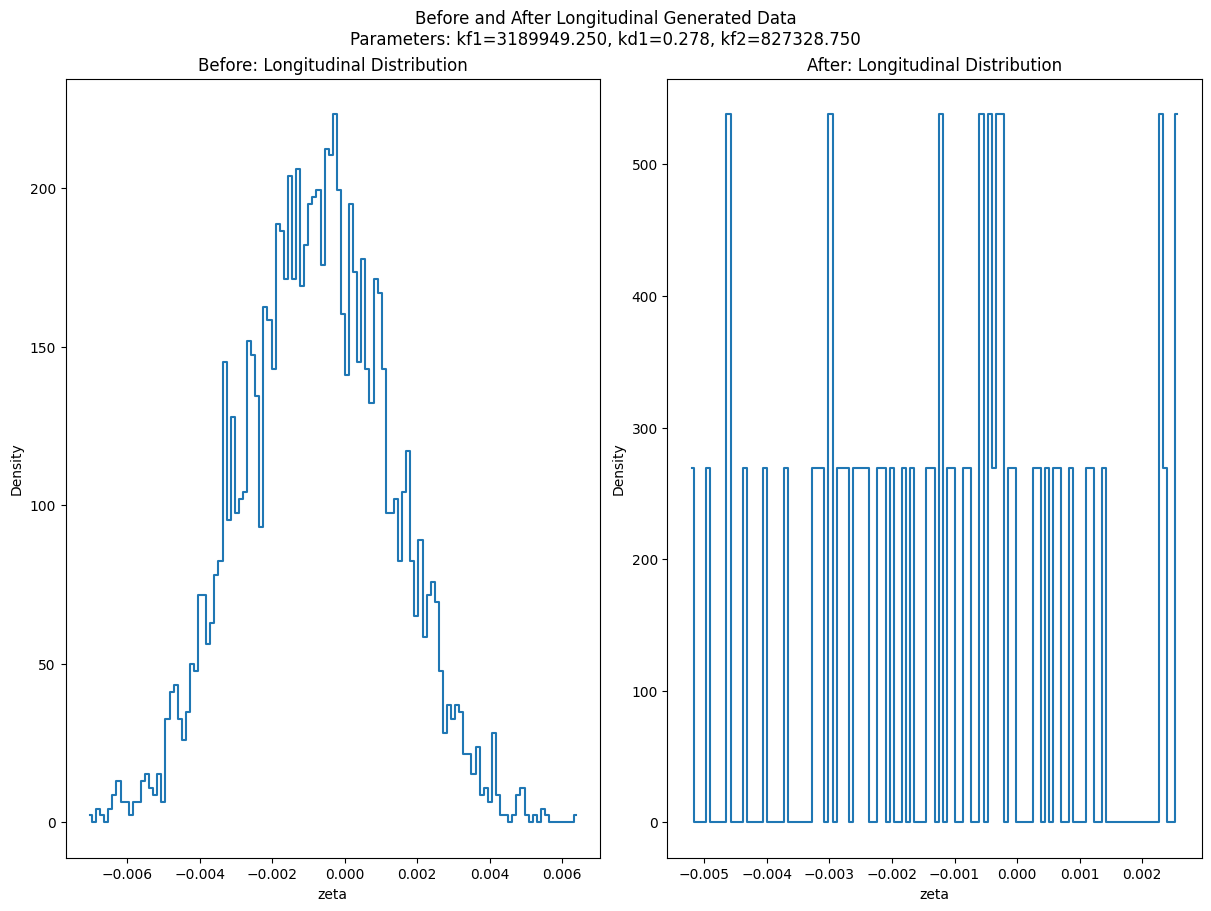

In [120]:
import matplotlib.pyplot as plt
def plot_longitudinal_distribution(i: int = 0, bins: int = 100, figsize: tuple = (12, 9), title: str = "Before and After Longitudinal Generated Data") -> None: 
    """
    Plot before/after histograms for the zeta distribution of the i-th example.

    Expects data dict with keys "X_cloud" and "Y_cloud" present in the notebook.
    """
    if "X_cloud" not in data or "Y_cloud" not in data:
        raise RuntimeError("data must contain 'X_cloud' and 'Y_cloud' arrays")

    X = data["X_cloud"]  # shape (n_samples, n_particles, 6)
    Y = data["Y_cloud"]
    MU = None
    if "MU" in data:
        MU = data["MU"]  # shape (n_samples, 3)
        if not (0 <= i < MU.shape[0]):
            raise IndexError(f"i out of range for MU (0 <= i < {MU.shape[0]})")
        mu_i = MU[i]
        title += f"\nParameters: kf1={mu_i[0]:.3f}, kd1={mu_i[1]:.3f}, kf2={mu_i[2]:.3f}"

    n_samples = X.shape[0]
    if not (0 <= i < n_samples):
        raise IndexError(f"i out of range (0 <= i < {n_samples})")

    z_before = X[i].astype(np.float64)  # (n_particles, 6)
    z_after = Y[i].astype(np.float64)
    mask_after = np.abs(z_after[:, 2]) < 4e-2
    z_after = z_after[mask_after]

    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

    for idx, (z, ax, label) in enumerate(zip([z_before, z_after], axes, ["Before", "After"])):
        hist, edges = np.histogram(z[:, 2], bins=bins, density=True)
        centers = 0.5 * (edges[:-1] + edges[1:])
        ax.plot(centers, hist, drawstyle="steps-mid")
        ax.set_title(f"{label}: Longitudinal Distribution")
        ax.set_xlabel("zeta")
        ax.set_ylabel("Density")

    fig.suptitle(title)
    plt.show()
    
rand_int = np.random.randint(0, data["X_cloud"].shape[0])  
plot_longitudinal_distribution(i=rand_int, bins=120)

In [45]:


from functools import partial

import numpy as np
import matplotlib.pyplot as plt

from pycolleff.longitudinal_equilibrium import ImpedanceSource, LongitudinalEquilibrium
import pycolleff.rings.sirius as sirius
import pycolleff.impedances as imp
import pycolleff.materials_params as mat_par



In [ ]:
def calculate_longitudinal_equilibrium(ring, impedance_sources, fill=None):
    """
    Calculate longitudinal equilibrium.
    """
    if fill is None:
        fill = np.ones(ring.harm_num) / ring.harm_num
    longeq = LongitudinalEquilibrium(
        ring=ring, impedance_sources=impedance_sources, fillpattern=fill)
    longeq.feedback_on = False  # main cavity is simulated with effective impedance
    longeq.zgrid = np.linspace(-1, 1, 2001) * ring.rf_lamb / 2
    longeq.max_mode = 1000*ring.harm_num  # define maximum frequency to consider
    longeq.min_mode0_ratio = 1e-10  # criteria for convergence

    print('Calculating Longitudinal Equilibrium...')
    _ = longeq.calc_longitudinal_equilibrium(
        niter=1000, tol=1e-8, beta=0.1, m=3, print_flag=True)
    return longeq





In [74]:
args = argparse.Namespace(
    n_samples=512,
    particles_per_sample=4096,
    nz = 256,
    seed=42,
    output_dir="./data/neural",
    train_fraction=0.8,
    val_fraction=0.1,
    gap_voltage_min=2.0e6,
    gap_voltage_max=5.0e6,
    current_min=350e-3,
    current_max=400e-2,
    rs_min=5.0e3,
    rs_max=3.0e6,
    Q=1.0e4,
    wr_scale=3.0,
    n_steps=3,
    mix=0.7,
)


rng = np.random.default_rng(24)
param_ranges = ParameterRanges(
        gap_voltage_V=(args.gap_voltage_min, args.gap_voltage_max),
        total_current_A=(args.current_min, args.current_max),
        shunt_impedance_Ohm=(args.rs_min, args.rs_max),
    )

mu = sample_mu(rng, param_ranges)

ring = sirius.create_ring()

ring.en_lost_rad = 870e3
ring.gap_voltage = 3.0e6
ring.total_current = 350e-3
print(ring)

Lattice Version             :   SI.v25.01-s05.02  
Circumference [m]           :       518.387       
Revolution Period [us]      :        1.729        
Revolution Frequency [kHz]  :       578.318       
Energy [GeV]                :        3.000        
U0 [keV]                    :       870.000       
Vgap [MV]                   :        3.000        
Momentum Compaction         :       1.63e-04      
Harmonic Number             :         864         
Current [mA]                :       350.000       
Current per Bunch [mA]      :        0.405        
Synchrotron Tune            :       0.00356       
Tunes x/y                   :    49.078/14.137    
Chromaticities x/y          :     2.500/2.500     
Damping Times x/y/e [ms]    :   16.9/ 22.0 /12.9  
Energy Spread [%]           :        0.0887       
Bunch Length [mm]           :        3.250        



calc_method         : ImpedanceDFT  
active_passive      : Passive  
ang_freq_rf         : 3139.50  [Mrad/s]
ang_freq            : 9418.78  [Mrad/s]
shunt_impedance     : 35000.00  [MOhm]
Q                   : 4.00e+08  
RoverQ              : 87.50  [Ohm]
harm_rf             : 3.00  
detune_angle        : 1.57  [rad]
detune_freq         : 45.00  [kHz]
detune_w            : 282743.34  [rad/s]
alpha               : 11.77  [rad/s]
ang_freq_bar        : 9418.78  [Mrad/s]

Calculating Longitudinal Equilibrium...
Iter.: 001, Dist. Diff.: 1.770e+00 (bucket 044), E.T.: 0.343s
--------------------
Iter.: 002, Dist. Diff.: 1.743e+00 (bucket 044), E.T.: 0.348s
--------------------
Iter.: 003, Dist. Diff.: 1.634e+00 (bucket 044), E.T.: 0.351s
--------------------
Iter.: 004, Dist. Diff.: 1.323e+00 (bucket 044), E.T.: 0.365s
--------------------
Iter.: 005, Dist. Diff.: 1.321e+00 (bucket 044), E.T.: 0.462s
--------------------
Iter.: 006, Dist. Diff.: 1.296e+00 (bucket 153), E.T.: 0.374s
----------

In [76]:
hcav = ImpedanceSource()
hcav.harm_rf = 3
hcav.Q = 4e8
RoverQ = 87.5
hcav.shunt_impedance = RoverQ * hcav.Q
twopi = 2 * np.pi
hcav.ang_freq_rf = twopi * ring.rf_freq
hcav.ang_freq = hcav.harm_rf * hcav.ang_freq_rf
hcav.detune_w = twopi * 45e3
hcav.calc_method = ImpedanceSource.Methods.ImpedanceDFT
hcav.active_passive = ImpedanceSource.ActivePassive.Passive
print(hcav)
longeq = calculate_longitudinal_equilibrium(ring, [hcav, ])

cu_cond = mat_par.cu_cond
cu_rel_time = mat_par.cu_rel_time
neg_cond = mat_par.neg_cond
neg_rel_time = mat_par.neg_rel_time
neg_thick = mat_par.neg_thick
ndfe_cond = mat_par.ndfe_cond
ndfe_mur = mat_par.ndfe_mur

energy = 3e9  # [eV]
length = 500  # [m] ~ ring size not considering IDs and injection

epb = np.array([1, 1, 1, 1, 1])
mub = np.array([1, 1, 1, 1, ndfe_mur])
ange = np.array([0, 0, 0, 0, 0])
angm = np.array([0, 0, 0, 0, 0])
sigmadc = np.array([0, neg_cond, cu_cond, 0, ndfe_cond])
tau = np.array([0, neg_rel_time, cu_rel_time, 0, 0])

radius = 12e-3 + np.array([-neg_thick, 0, 1e-3, 3e-3])

ang_freq = imp.get_default_reswall_w(radius=radius[0], energy=energy)

epr, mur = imp.prepare_inputs_epr_mur(
    ang_freq, epb, mub, ange, angm, sigmadc, tau)

Zll, Zdx, Zdy = imp.multilayer_round_chamber(
    ang_freq,
    length,
    energy,
    epr,
    mur,
    radius,
    precision=70,
    wmax_arb_prec=1e12,
    arb_prec_incl_long=False,
    print_progress=True,
)

Zll, ang_freq = imp.get_impedance_for_negative_w(
    Zll, ang_freq, impedance_type='ll'
)

generic = ImpedanceSource()
generic.zl_table = Zll
generic.ang_freq_table = ang_freq

# Methods: Impedance or Wake
generic.calc_method = ImpedanceSource.Methods.ImpedanceDFT

# Device type: Active of Passive
generic.active_passive = ImpedanceSource.ActivePassive.Passive

longeq = calculate_longitudinal_equilibrium(ring, [generic,hcav ])

0000/0302 -> freq =        0.1  (ET: 0.07 s)
0001/0302 -> freq =       0.11  (ET: 0.07 s)
0002/0302 -> freq =       0.12  (ET: 0.07 s)
0003/0302 -> freq =       0.13  (ET: 0.07 s)
0004/0302 -> freq =       0.15  (ET: 0.08 s)
0005/0302 -> freq =       0.16  (ET: 0.07 s)
0006/0302 -> freq =       0.17  (ET: 0.08 s)
0007/0302 -> freq =       0.19  (ET: 0.07 s)
0008/0302 -> freq =       0.21  (ET: 0.07 s)
0009/0302 -> freq =       0.23  (ET: 0.07 s)
0010/0302 -> freq =       0.25  (ET: 0.07 s)
0011/0302 -> freq =       0.28  (ET: 0.08 s)
0012/0302 -> freq =       0.31  (ET: 0.07 s)
0013/0302 -> freq =       0.34  (ET: 0.08 s)
0014/0302 -> freq =       0.37  (ET: 0.08 s)
0015/0302 -> freq =        0.4  (ET: 0.08 s)
0016/0302 -> freq =       0.44  (ET: 0.07 s)
0017/0302 -> freq =       0.49  (ET: 0.08 s)
0018/0302 -> freq =       0.53  (ET: 0.08 s)
0019/0302 -> freq =       0.59  (ET: 0.08 s)
0020/0302 -> freq =       0.64  (ET: 0.08 s)
0021/0302 -> freq =       0.71  (ET: 0.08 s)
0022/0302 

Bunch 0 centroid: -0.25 mm
Bunch 0 length: 11.94 mm


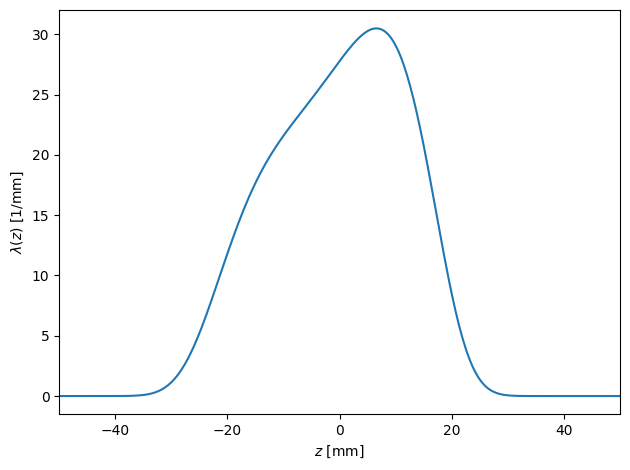

In [107]:
print_results(longeq)